# 3 — Warps, simulation and registration accuracy

This notebook demonstrates the warp utilities in `reg1d.warp` (composition, inversion,
displacement fields, Karcher means, random warps) and uses simulated data with known warps to check
how accurately each nonlinear method recovers them.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))   # so that this notebook finds registration1d without installation
import numpy as np
from matplotlib import pyplot as plt
import registration1d as reg1d
print('registration1d version:', reg1d.__version__)

registration1d version: 0.0.2


### Random warps

`random_warp` draws warps as random points on the unit sphere of the square-root-slope
representation ψ = √γ′ (the construction used in the SRSF literature). `sigma` controls the
strength and `n_basis` the roughness.

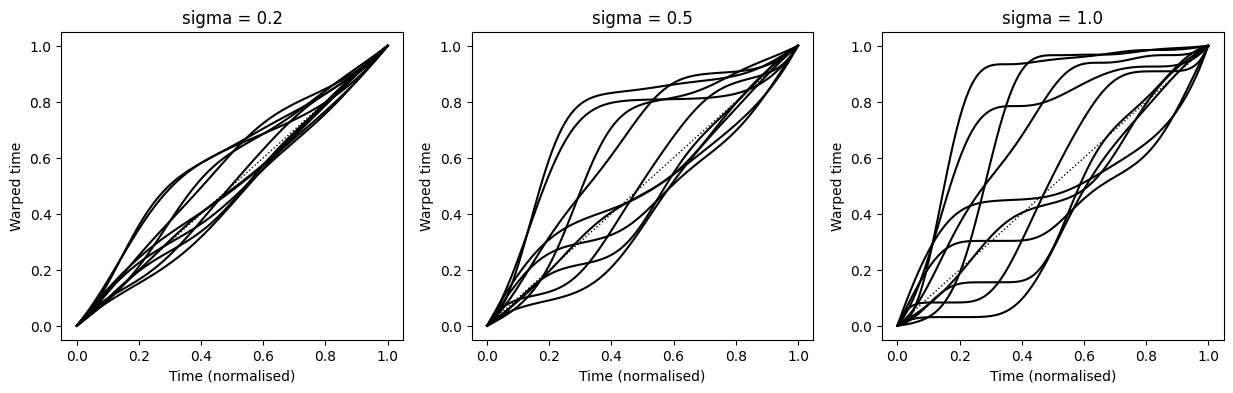

In [2]:
t  = np.linspace(0, 1, 101)
fig,AX = plt.subplots(1, 3, figsize=(15,4))
for ax,sigma in zip(AX, [0.2, 0.5, 1.0]):
    w = reg1d.random_warp(J=10, Q=101, sigma=sigma, random_state=0)
    reg1d.plot.plot_warps(w, ax=ax, legend=False)
    ax.set_title(f'sigma = {sigma}')
plt.show()

### Warp algebra

`Warp1D` objects support application to data, composition and inversion; `Warp1DList` adds
Karcher means and centring. Inversion followed by composition returns the identity to within
interpolation error.

max |w o w^-1 - t| = 1.703515106754594e-11


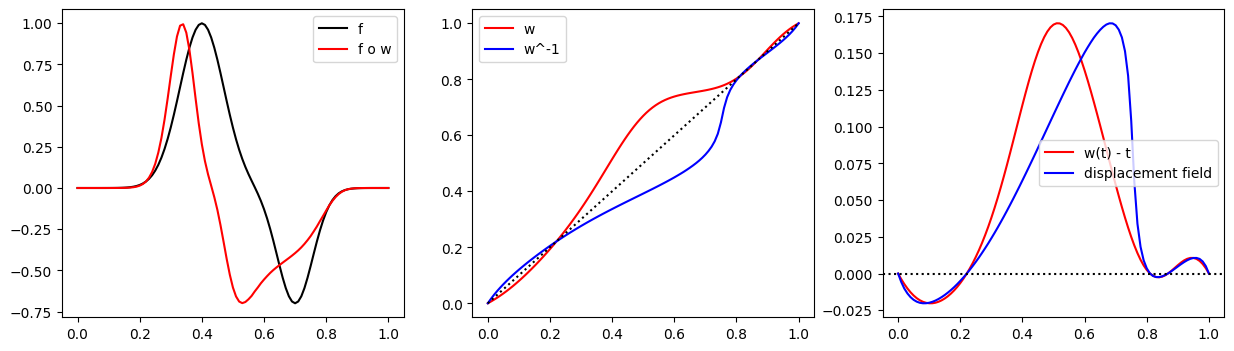

In [3]:
w   = reg1d.Warp1D( reg1d.random_warp(Q=101, sigma=0.5, random_state=1) )
wi  = w.inverse()
print('max |w o w^-1 - t| =', np.abs(w.compose(wi).w - t).max())

f   = np.exp(-((t-0.4)/0.1)**2) - 0.7*np.exp(-((t-0.7)/0.08)**2)
fw  = w.apply(f)                  # f( w(t) )
fig,AX = plt.subplots(1, 3, figsize=(15,4))
AX[0].plot(t, f, 'k', label='f'); AX[0].plot(t, fw, 'r', label='f o w'); AX[0].legend()
AX[1].plot(t, w.w, 'r', label='w'); AX[1].plot(t, wi.w, 'b', label='w^-1'); AX[1].plot([0,1],[0,1],'k:'); AX[1].legend()
AX[2].plot(t, w.displacement(), 'r', label='w(t) - t'); AX[2].plot(t, w.displacement_field(), 'b', label='displacement field'); AX[2].axhline(0, color='k', ls=':'); AX[2].legend()
plt.show()

### Karcher mean and centring

A set of warps is centred by composing each with the inverse of their Karcher mean; the Karcher
mean of the centred set is the identity. Registration functions with `center=True` (the default
for SRSF and continuous registration) do this automatically so that the registered data keep the
average timing of the original data.

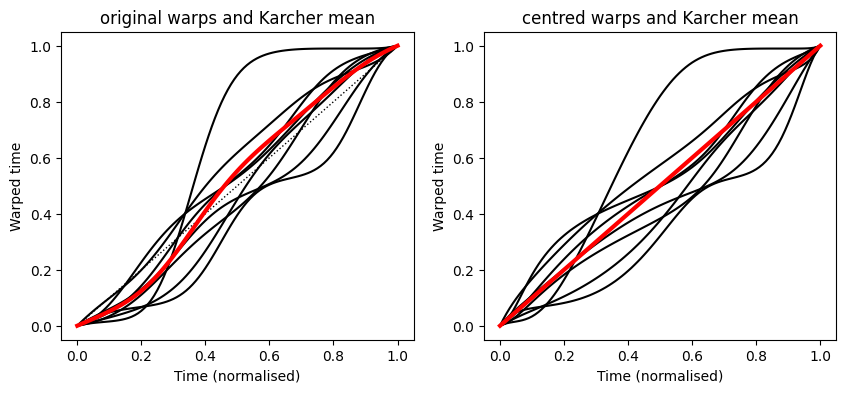

In [4]:
W  = reg1d.Warp1DList( reg1d.random_warp(J=8, Q=101, sigma=0.5, random_state=2) )
Wc = W.center()
fig,AX = plt.subplots(1, 2, figsize=(10,4))
W.plot(ax=AX[0], legend=False);  AX[0].plot(t, W.mean().w, 'r', lw=3);  AX[0].set_title('original warps and Karcher mean')
Wc.plot(ax=AX[1], legend=False); AX[1].plot(t, Wc.mean().w, 'r', lw=3); AX[1].set_title('centred warps and Karcher mean')
plt.show()

### Recovery of known warps

A smooth template is warped by random warps, and each method is asked to undo the warping. The
recovered warps are compared with the truth after both are centred (registration can only
recover warps up to a common warp of the template). Note that the template is flat near both
ends of the domain, where no method can identify the warp; the parametric (continuous) method
extrapolates its smooth warp into those regions whereas the dynamic-programming methods default
to a straight path, which is the main source of the difference in warp error below.

method         RMS warp error   residual SSE


srsf                   0.0416         0.9177


dtw                    0.0423         0.2865
landmark               0.0455        10.8198


continuous             0.0570        11.1270


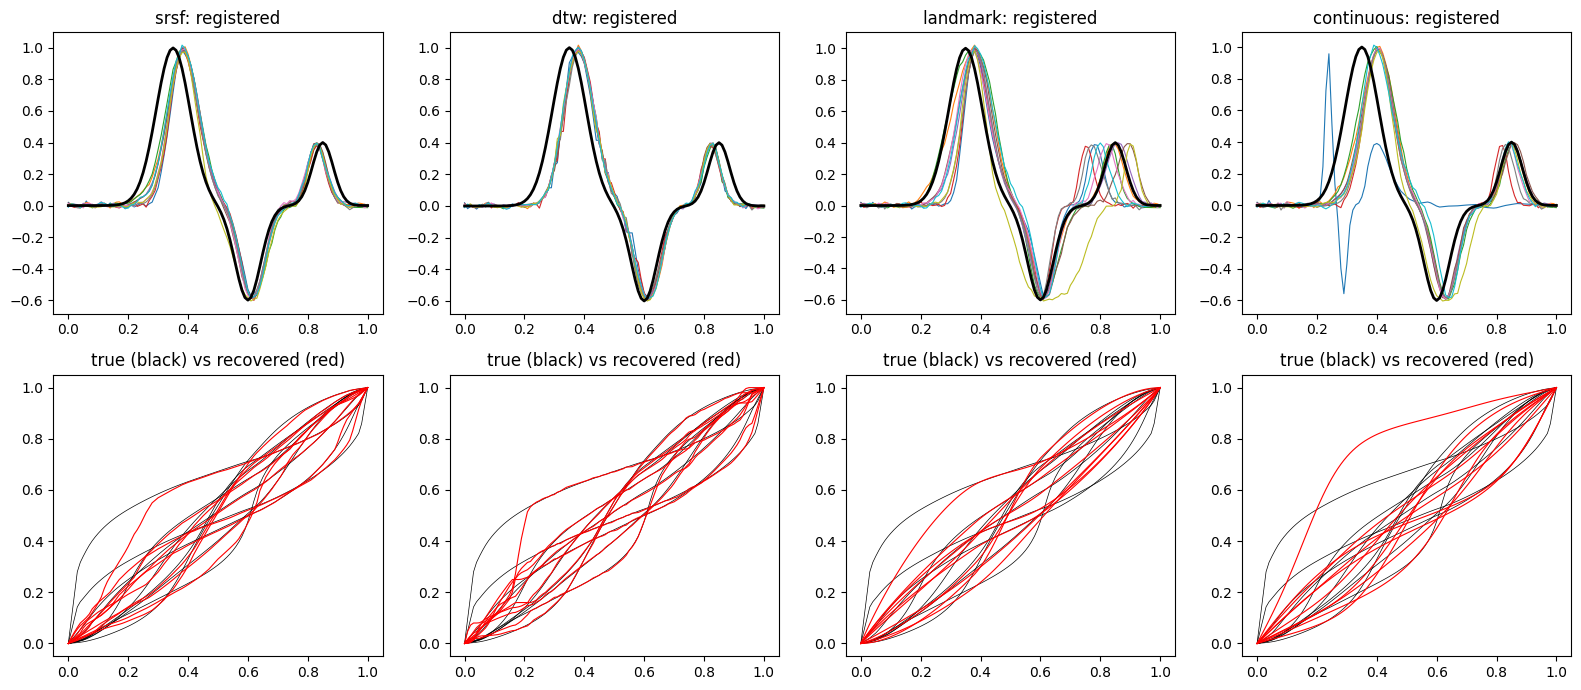

In [5]:
rng   = np.random.default_rng(3)
J     = 10
f0    = np.exp(-((t-0.35)/0.08)**2) - 0.6*np.exp(-((t-0.6)/0.06)**2) + 0.4*np.exp(-((t-0.85)/0.05)**2)
wtrue = reg1d.random_warp(J=J, Q=101, sigma=0.4, n_basis=3, random_state=3)
y     = np.array([reg1d.warp.apply_warp(f0, w) for w in wtrue])      # y_i = f0 o w_i
y    += 0.01 * rng.standard_normal(y.shape)

# the registration warp should be (approximately) the inverse of the generating warp
winv  = reg1d.warp.center_warps( reg1d.warp.invert(wtrue) )[0]

methods = {
    'srsf'       : lambda y: reg1d.register_srsf(y),
    'dtw'        : lambda y: reg1d.register_dtw(y),
    'landmark'   : lambda y: reg1d.register_landmark(y, kinds=('min','max')),
    'continuous' : lambda y: reg1d.register_continuous(y, n_basis=6),
}
fig,AX = plt.subplots(2, 4, figsize=(16,7))
print(f"{'method':12s} {'RMS warp error':>16s} {'residual SSE':>14s}")
for k,(name,fn) in enumerate(methods.items()):
    r    = fn(y)
    wrec = reg1d.warp.center_warps(r.warps.asarray())[0]
    err  = np.sqrt(((wrec - winv)**2).mean())
    print(f"{name:12s} {err:16.4f} {r.sse()[1]:14.4f}")
    AX[0,k].plot(t, r.y.T, lw=0.8); AX[0,k].plot(t, f0, 'k', lw=2); AX[0,k].set_title(f'{name}: registered')
    AX[1,k].plot(t, winv.T, 'k', lw=0.5); AX[1,k].plot(t, wrec.T, 'r', lw=0.8); AX[1,k].set_title('true (black) vs recovered (red)')
plt.tight_layout()
plt.show()

### Elastic distances

`reg1d.srsf` also provides the amplitude and phase distances of the SRSF framework, which are
useful for clustering and hypothesis testing on timing versus amplitude effects.

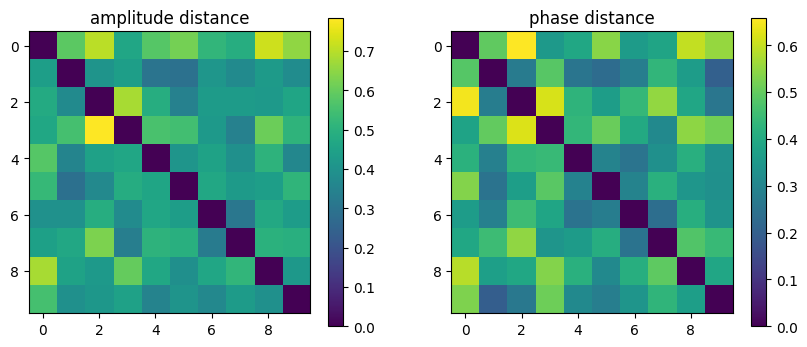

In [6]:
d_amp = np.array([[reg1d.srsf.amplitude_distance(a, b) for b in y] for a in y])
d_pha = np.array([[reg1d.srsf.phase_distance(a, b) for b in y] for a in y])
fig,AX = plt.subplots(1, 2, figsize=(10,4))
for ax,D,s in zip(AX, [d_amp, d_pha], ['amplitude distance', 'phase distance']):
    im = ax.imshow(D, cmap='viridis'); ax.set_title(s); plt.colorbar(im, ax=ax)
plt.show()